SIMON'S ALGORITHM - EASY
Secret string: 110

SIMON ORACLE CIRCUIT
     ┌────────────┐
q_0: ┤0           ├
     │            │
q_1: ┤1           ├
     │            │
q_2: ┤2           ├
     │  Oracle Uf │
q_3: ┤3           ├
     │            │
q_4: ┤4           ├
     │            │
q_5: ┤5           ├
     └────────────┘

TRUTH TABLE
x     f(x)    f(x XOR s)    Correct
---------------------------------------------
000    000       000          True
001    001       001          True
010    010       010          True
011    011       011          True
100    010       010          True
101    011       011          True
110    000       000          True
111    001       001          True

ORACLE VERIFICATION
Oracle correctness verified successfully.
For every x:
f(x) = f(x XOR s)

SIMON PROPERTY
Secret string s = 110
The oracle satisfies:
f(x) = f(x XOR s)
Therefore, the oracle is consistent with Simon's promise.


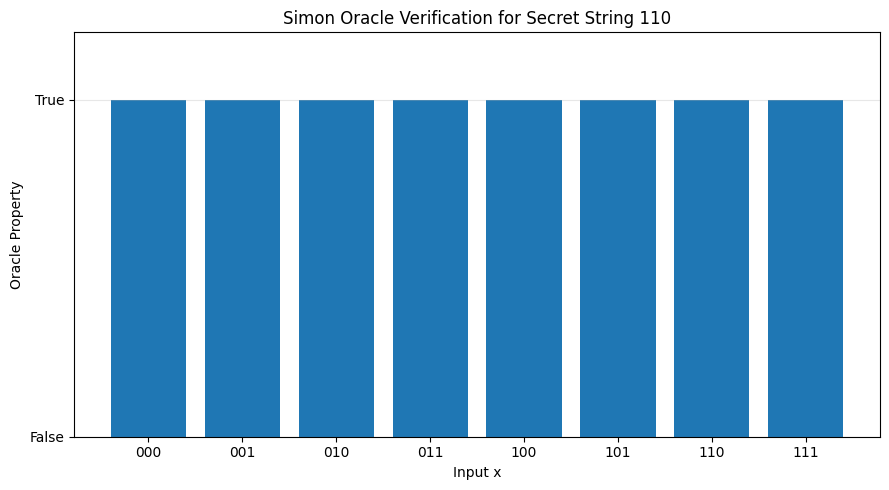

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit

SECRET = "110"
N = len(SECRET)

def xor_bits(a, b):
    return "".join(str(int(x) ^ int(y)) for x, y in zip(a, b))

def dot_product_mod2(a, b):
    return sum(int(x) * int(y) for x, y in zip(a, b)) % 2

def simon_function(x, secret):
    partner = xor_bits(x, secret)
    return min(x, partner)

def create_oracle(secret):
    n = len(secret)
    size = 2 ** (2 * n)
    matrix = np.zeros((size, size), dtype=complex)

    for x_int in range(2 ** n):
        x = format(x_int, f"0{n}b")
        fx = simon_function(x, secret)

        for y_int in range(2 ** n):
            y = format(y_int, f"0{n}b")
            output = xor_bits(y, fx)

            input_index = x_int * (2 ** n) + y_int
            output_index = x_int * (2 ** n) + int(output, 2)

            matrix[output_index, input_index] = 1

    return matrix

print("SIMON'S ALGORITHM - EASY")
print("=" * 60)
print(f"Secret string: {SECRET}")

oracle = create_oracle(SECRET)

qc = QuantumCircuit(2 * N)

qc.unitary(oracle, range(2 * N), label="Oracle Uf")

print("\nSIMON ORACLE CIRCUIT")
print("=" * 60)
print(qc.draw())

print("\nTRUTH TABLE")
print("=" * 60)
print("x     f(x)    f(x XOR s)    Correct")
print("-" * 45)

all_correct = True

for x_int in range(2 ** N):
    x = format(x_int, f"0{N}b")
    x_xor_s = xor_bits(x, SECRET)

    fx = simon_function(x, SECRET)
    fx_xor_s = simon_function(x_xor_s, SECRET)

    correct = fx == fx_xor_s

    if not correct:
        all_correct = False

    print(f"{x}    {fx}       {fx_xor_s}          {correct}")

print("\nORACLE VERIFICATION")
print("=" * 60)

if all_correct:
    print("Oracle correctness verified successfully.")
    print("For every x:")
    print("f(x) = f(x XOR s)")
else:
    print("Oracle verification failed.")

print("\nSIMON PROPERTY")
print("=" * 60)

print(f"Secret string s = {SECRET}")
print("The oracle satisfies:")
print("f(x) = f(x XOR s)")
print("Therefore, the oracle is consistent with Simon's promise.")

x_values = []
same_values = []

for x_int in range(2 ** N):
    x = format(x_int, f"0{N}b")
    partner = xor_bits(x, SECRET)

    x_values.append(x)
    same_values.append(
        simon_function(x, SECRET) == simon_function(partner, SECRET)
    )

plt.figure(figsize=(9, 5))

plt.bar(
    x_values,
    [1 if value else 0 for value in same_values]
)

plt.xlabel("Input x")
plt.ylabel("Oracle Property")
plt.title("Simon Oracle Verification for Secret String 110")
plt.yticks([0, 1], ["False", "True"])
plt.ylim(0, 1.2)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()